#  Network Intrusion Detection System — RF vs XGBoost (GPU L4)
## Dataset: UNSW-NB15 | Task: Binary Classification (Normal vs Attack)
## Environment: Google Colab — NVIDIA L4 GPU

### Pipeline Overview
1. GPU Setup & Environment Check
2. Google Drive Mount & Data Loading
3. Preprocessing (Cleaning, Encoding, Scaling)
4. Feature Selection (Mutual Information + Correlation)
5. Train/Test Split + SMOTE Oversampling
6. Random Forest (CPU scikit-learn)
7. XGBoost (GPU — `device='cuda'`)
8. Hyperparameter Tuning (RandomizedSearchCV)
9. Optimal Threshold — Youden's J
10. Evaluation & Comparison Plots
11. Feature Importance
12. Final Results Summary

---
## 1. GPU Setup & Environment Check

In [20]:
# Verify GPU availability — make sure Runtime > Change runtime type > L4 GPU

import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

import torch
print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
    print(f'VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Tue Mar 24 18:31:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   43C    P8             16W /   72W |       3MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [21]:
# Install / upgrade required libraries
!pip install -q xgboost --upgrade
!pip install -q imbalanced-learn scikit-learn pandas numpy matplotlib seaborn

import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import LabelEncoder, QuantileTransformer
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, accuracy_score, average_precision_score,
    precision_score, recall_score
)
from imblearn.over_sampling import SMOTE
from scipy.stats import randint, uniform
import xgboost as xgb

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print(f'XGBoost version : {xgb.__version__}')
print(' All libraries imported successfully')

XGBoost version : 3.2.0
 All libraries imported successfully


---
## 2. Google Drive Mount & Data Loading

In [22]:
from google.colab import drive
drive.mount('/content/drive')
print(' Google Drive mounted')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Google Drive mounted


In [23]:
DATA_PATH        = '/content/drive/MyDrive/Tez_kodu/UNSW-NB15'

In [24]:
if os.path.isdir(DATA_PATH):
    csv_files = glob.glob(os.path.join(DATA_PATH, '*.csv'))
    print(f'{len(csv_files)} CSV files found:')
    for f in csv_files:
        print(f'   {os.path.basename(f)}')
    df = pd.concat([pd.read_csv(f, low_memory=False) for f in csv_files], ignore_index=True)
else:
    df = pd.read_csv(DATA_PATH, low_memory=False)

df.columns = df.columns.str.strip().str.lower()
print(f'\nShape: {df.shape}')
print(f'Columns sample: {list(df.columns[:8])}')

2 CSV files found:
   UNSW_NB15_training-set.csv
   UNSW_NB15_testing-set.csv

Shape: (257673, 45)
Columns sample: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes']


In [25]:
print('--- Columns ---')
print(df.columns.tolist())
print(f'\n--- Label distribution (label) ---')
print(df['label'].value_counts())
print(f'\n--- Attack categories ---')
df['attack_cat'].fillna('Normal', inplace=True)
print(df['attack_cat'].value_counts())
df.head()

--- Columns ---
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

--- Label distribution (label) ---
label
1    164673
0     93000
Name: count, dtype: int64

--- Attack categories ---
attack_cat
Normal            93000
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Worms               174
Name: count, dtype: int64


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


---
## 3. Preprocessing

Binary label distribution:
Attack    164673
Normal     93000
Name: count, dtype: int64
Imbalance ratio: 0.56:1


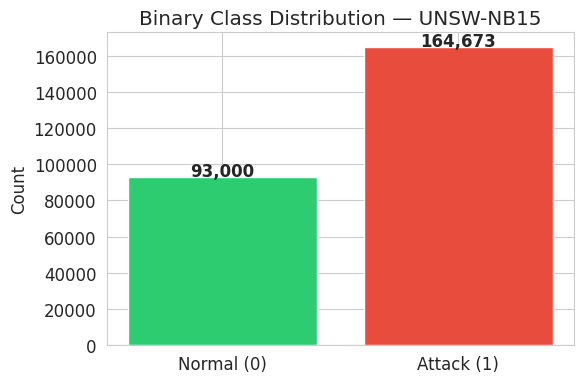

In [26]:
# 3.1 Binary label — 'label' column: 0=Normal, 1=Attack (already binary)

LABEL_COL = 'label'
y = df[LABEL_COL].astype(int).values

print('Binary label distribution:')
print(pd.Series(y).value_counts().rename({0: 'Normal', 1: 'Attack'}))
print(f'Imbalance ratio: {(y==0).sum() / (y==1).sum():.2f}:1')

# Visualize
fig, ax = plt.subplots(figsize=(6, 4))
counts = pd.Series(y).value_counts().sort_index()
ax.bar(['Normal (0)', 'Attack (1)'], counts.values, color=['#2ecc71', '#e74c3c'])
ax.set_title('Binary Class Distribution — UNSW-NB15')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# 3.2 Drop non-informative columns

DROP_COLS = ['label', 'attack_cat', 'srcip', 'dstip', 'Stime', 'Ltime']
DROP_COLS = [c for c in DROP_COLS if c in df.columns]

X = df.drop(columns=DROP_COLS).copy()

# Encode categorical columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Categorical columns to encode: {cat_cols}')

le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print(f'Feature matrix shape: {X.shape}')

Categorical columns to encode: ['proto', 'service', 'state']
Feature matrix shape: (257673, 43)


In [28]:
# 3.3 Handle Infinite & Missing Values

X.replace([np.inf, -np.inf], np.nan, inplace=True)
nan_count = X.isnull().sum().sum()
print(f'NaN values before fill: {nan_count}')
X.fillna(X.median(numeric_only=True), inplace=True)
print(f'NaN values after fill : {X.isnull().sum().sum()}')
print(' Inf/NaN handled')

NaN values before fill: 0
NaN values after fill : 0
 Inf/NaN handled


In [29]:
# 3.4 Remove Zero-Variance Features

vt = VarianceThreshold(threshold=0.0)
vt.fit(X)
removed = X.columns[~vt.get_support()].tolist()
print(f'Zero-variance features removed: {len(removed)} → {removed}')
X = X[X.columns[vt.get_support()]]

# 3.5 Remove Highly Correlated Features (|r| > 0.95)

corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f'High-correlation features removed (|r|>0.95): {len(high_corr)}')
X.drop(columns=high_corr, inplace=True)
print(f'Final feature matrix shape: {X.shape}')

Zero-variance features removed: 0 → []
High-correlation features removed (|r|>0.95): 9
Final feature matrix shape: (257673, 34)


---
## 4. Feature Selection (Mutual Information)

Computing Mutual Information scores...

Top 20 features by Mutual Information:
     feature  mi_score
ct_state_ttl  0.340695
       sload  0.340416
        sttl  0.339211
       smean  0.333236
          id  0.325267
        dttl  0.314586
        rate  0.313708
         dur  0.302250
       dmean  0.282665
      dinpkt  0.271285
       dload  0.251515
       dpkts  0.242955
      sinpkt  0.224887
      synack  0.217960
      tcprtt  0.217832
      ackdat  0.209490
       state  0.195783
        sjit  0.185268
        djit  0.162198
       spkts  0.161288


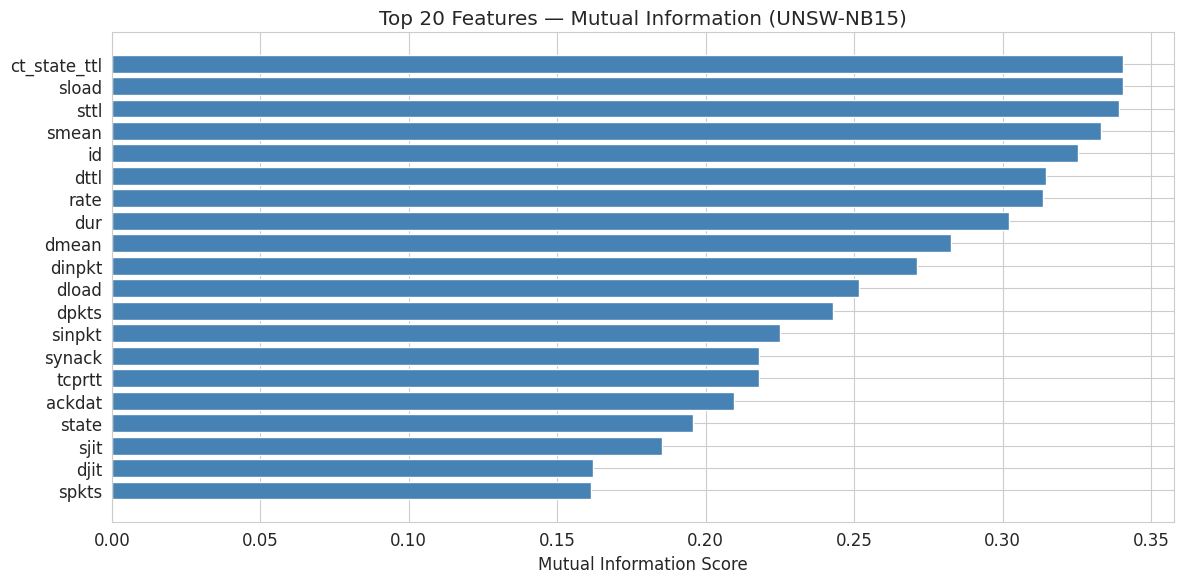

In [30]:
print('Computing Mutual Information scores...')
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({'feature': X.columns, 'mi_score': mi_scores})
mi_df.sort_values('mi_score', ascending=False, inplace=True)

print('\nTop 20 features by Mutual Information:')
print(mi_df.head(20).to_string(index=False))

# Plot
top20 = mi_df.head(20)
plt.figure(figsize=(12, 6))
plt.barh(top20['feature'][::-1], top20['mi_score'][::-1], color='steelblue')
plt.xlabel('Mutual Information Score')
plt.title('Top 20 Features — Mutual Information (UNSW-NB15)')
plt.tight_layout()
plt.savefig('mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
TOP_K = 30
selected_features = mi_df.head(TOP_K)['feature'].tolist()
X_selected = X[selected_features].copy()
print(f'Selected top {TOP_K} features. Shape: {X_selected.shape}')

Selected top 30 features. Shape: (257673, 30)


---
## 5. Train/Test Split + Scaling + SMOTE

In [32]:
# Stratified Train / Validation / Test split (70 / 10 / 20)

# Step 1: isolate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_selected, y, test_size=0.20, random_state=42, stratify=y
)

# Step 2: split remaining 80% into train (70%) and val (10%)
# 10/80 = 0.125 to get exactly 10% of total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

print(f'Total samples   : {len(y):,}')
print(f'Train      : {X_train.shape[0]:,}  ({X_train.shape[0]/len(y)*100:.0f}%) | Class dist: {np.bincount(y_train)}')
print(f'Validation : {X_val.shape[0]:,}   ({X_val.shape[0]/len(y)*100:.0f}%)  | Class dist: {np.bincount(y_val)}')
print(f'Test       : {X_test.shape[0]:,}   ({X_test.shape[0]/len(y)*100:.0f}%)  | Class dist: {np.bincount(y_test)}')

# QuantileTransformer scaling — fit on train only
scaler = QuantileTransformer(output_distribution='normal', random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
print('Scaling done (QuantileTransformer)')

# SMOTE-Tomek on training set only
print(f'\nBefore SMOTE: {np.bincount(y_train)}')
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print(f'After  SMOTE: {np.bincount(y_train_res)}')
print(f'Training set size: {X_train_res.shape[0]:,} samples')

Total samples   : 257,673
Train      : 180,370  (70%) | Class dist: [ 65100 115270]
Validation : 25,768   (10%)  | Class dist: [ 9300 16468]
Test       : 51,535   (20%)  | Class dist: [18600 32935]
Scaling done (QuantileTransformer)

Before SMOTE: [ 65100 115270]
After  SMOTE: [115270 115270]
Training set size: 230,540 samples


---
## 6. Random Forest (CPU)

In [37]:
# scikit-learn RF runs on CPU (all cores via n_jobs=-1)

print('Training Random Forest...')
t0 = time.time()

rf_param_dist = {
    'n_estimators'      : randint(100, 500),
    'max_depth'         : [None, 10, 20, 30, 50],
    'min_samples_split' : randint(2, 20),
    'min_samples_leaf'  : randint(1, 10),
    'max_features'      : ['sqrt', 'log2', 0.3, 0.5],
    'criterion'         : ['gini', 'entropy']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_res, y_train_res)
rf_time = time.time() - t0

best_rf = rf_search.best_estimator_
y_pred_rf   = best_rf.predict(X_test_scaled)
y_prob_rf   = best_rf.predict_proba(X_test_scaled)[:, 1]

print(f'\n RF Training time  : {rf_time:.1f}s')
print(f'Best CV F1           : {rf_search.best_score_:.4f}')
print(f'Test Accuracy        : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Test F1              : {f1_score(y_test, y_pred_rf):.4f}')
print(f'Test ROC-AUC         : {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'\nBest params: {rf_search.best_params_}')

Training Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

 RF Training time  : 5068.8s
Best CV F1           : 0.9831
Test Accuracy        : 0.9854
Test F1              : 0.9885
Test ROC-AUC         : 0.9989

Best params: {'criterion': 'entropy', 'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 9, 'n_estimators': 487}


---
## 7. XGBoost (GPU — device='cuda')

In [35]:
# XGBoost with device='cuda' uses the L4 GPU fully
# scale_pos_weight handles class imbalance

scale_pos = int((y_train_res == 0).sum() / (y_train_res == 1).sum())
print(f'scale_pos_weight: {scale_pos}')

xgb_param_dist = {
    'n_estimators'      : randint(100, 600),
    'max_depth'         : randint(3, 12),
    'learning_rate'     : uniform(0.01, 0.3),
    'subsample'         : uniform(0.6, 0.4),
    'colsample_bytree'  : uniform(0.6, 0.4),
    'min_child_weight'  : randint(1, 10),
    'gamma'             : uniform(0, 0.5),
    'reg_alpha'         : uniform(0, 1.0),
    'reg_lambda'        : uniform(0.5, 2.0),
}

xgb_base = xgb.XGBClassifier(
    device='cuda',                  # ← GPU L4
    tree_method='hist',             # histogram-based on GPU
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos,
    random_state=42,
    verbosity=0
)

print('\nStarting XGBoost RandomizedSearchCV on GPU L4...')
t0 = time.time()

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=40,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1,
    random_state=42,
    n_jobs=1         # XGBoost handles parallelism internally on GPU
)

xgb_search.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

xgb_time = time.time() - t0

best_xgb = xgb_search.best_estimator_
y_pred_xgb  = best_xgb.predict(X_test_scaled)
y_prob_xgb  = best_xgb.predict_proba(X_test_scaled)[:, 1]

print(f'\n XGBoost Training time : {xgb_time:.1f}s')
print(f'Best CV F1               : {xgb_search.best_score_:.4f}')
print(f'Test Accuracy            : {accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'Test F1                  : {f1_score(y_test, y_pred_xgb):.4f}')
print(f'Test ROC-AUC             : {roc_auc_score(y_test, y_prob_xgb):.4f}')
print(f'\nBest params: {xgb_search.best_params_}')

scale_pos_weight: 1

Starting XGBoost RandomizedSearchCV on GPU L4...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

 XGBoost Training time : 203.1s
Best CV F1               : 0.9865
Test Accuracy            : 0.9854
Test F1                  : 0.9885
Test ROC-AUC             : 0.9991

Best params: {'colsample_bytree': np.float64(0.7941119497105262), 'gamma': np.float64(0.18634343354702465), 'learning_rate': np.float64(0.12840744004284166), 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 459, 'reg_alpha': np.float64(0.0704161308495439), 'reg_lambda': np.float64(0.9178374352307204), 'subsample': np.float64(0.8684574067296202)}


---
## 8. Optimal Threshold — Youden's J (Both Models)

In [38]:
def youden_threshold(y_true, y_prob):
    """Find optimal threshold using Youden's J statistic."""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j_scores = tpr - fpr
    idx = np.argmax(j_scores)
    return thresholds[idx], fpr, tpr, thresholds, j_scores, idx

# RF optimal threshold
rf_thresh, rf_fpr, rf_tpr, rf_thresholds, rf_j, rf_idx = youden_threshold(y_test, y_prob_rf)
y_pred_rf_opt = (y_prob_rf >= rf_thresh).astype(int)

# XGBoost optimal threshold
xgb_thresh, xgb_fpr, xgb_tpr, xgb_thresholds, xgb_j, xgb_idx = youden_threshold(y_test, y_prob_xgb)
y_pred_xgb_opt = (y_prob_xgb >= xgb_thresh).astype(int)

print(f'RF  optimal threshold  : {rf_thresh:.4f}')
print(f'XGB optimal threshold  : {xgb_thresh:.4f}')

RF  optimal threshold  : 0.5093
XGB optimal threshold  : 0.5589


---
## 9. Evaluation & Comparison Plots

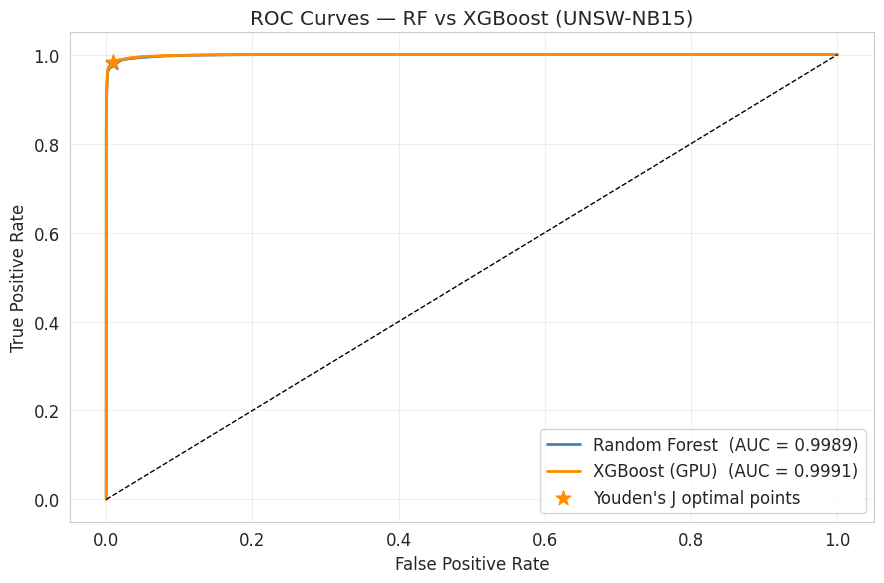

 roc_comparison.png saved


In [39]:
# Plot 1: ROC Curves — RF vs XGBoost

rf_auc  = roc_auc_score(y_test, y_prob_rf)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(9, 6))
plt.plot(rf_fpr,  rf_tpr,  color='steelblue',  lw=2, label=f'Random Forest  (AUC = {rf_auc:.4f})')
plt.plot(xgb_fpr, xgb_tpr, color='darkorange', lw=2, label=f'XGBoost (GPU)  (AUC = {xgb_auc:.4f})')
plt.scatter(rf_fpr[rf_idx],   rf_tpr[rf_idx],   s=120, color='steelblue',  zorder=5, marker='*')
plt.scatter(xgb_fpr[xgb_idx], xgb_tpr[xgb_idx], s=120, color='darkorange', zorder=5, marker='*',
            label="Youden's J optimal points")
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — RF vs XGBoost (UNSW-NB15)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(' roc_comparison.png saved')

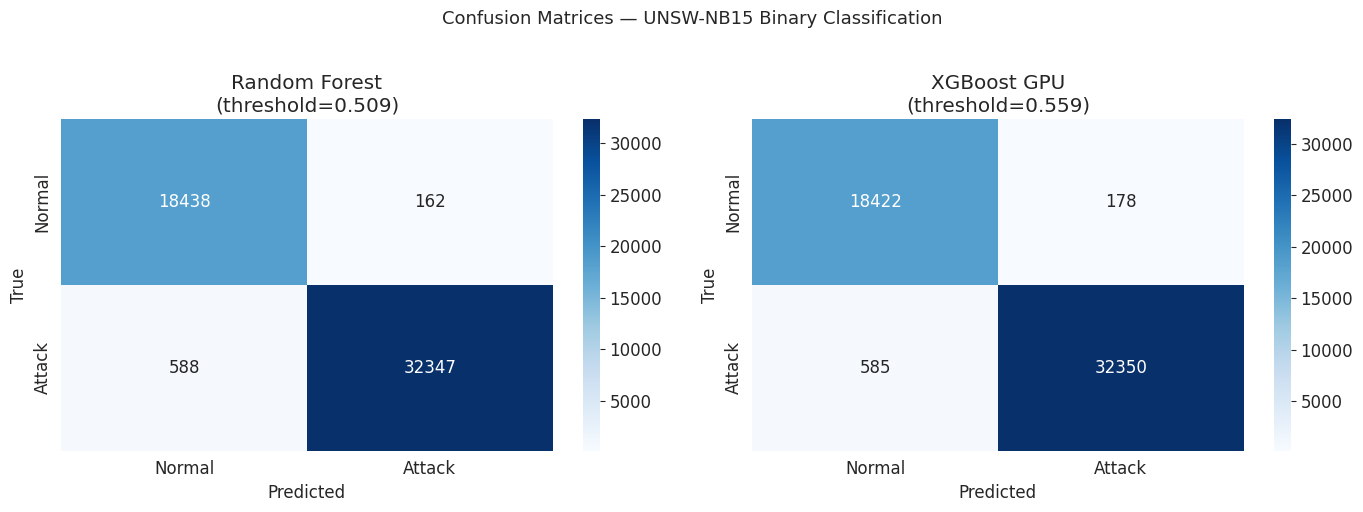

 confusion_matrices.png saved


In [40]:
# Plot 2: Confusion Matrices side by side

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in [
    (axes[0], y_pred_rf_opt,  f'Random Forest\n(threshold={rf_thresh:.3f})'),
    (axes[1], y_pred_xgb_opt, f'XGBoost GPU\n(threshold={xgb_thresh:.3f})')
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal','Attack'],
                yticklabels=['Normal','Attack'])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion Matrices — UNSW-NB15 Binary Classification', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(' confusion_matrices.png saved')

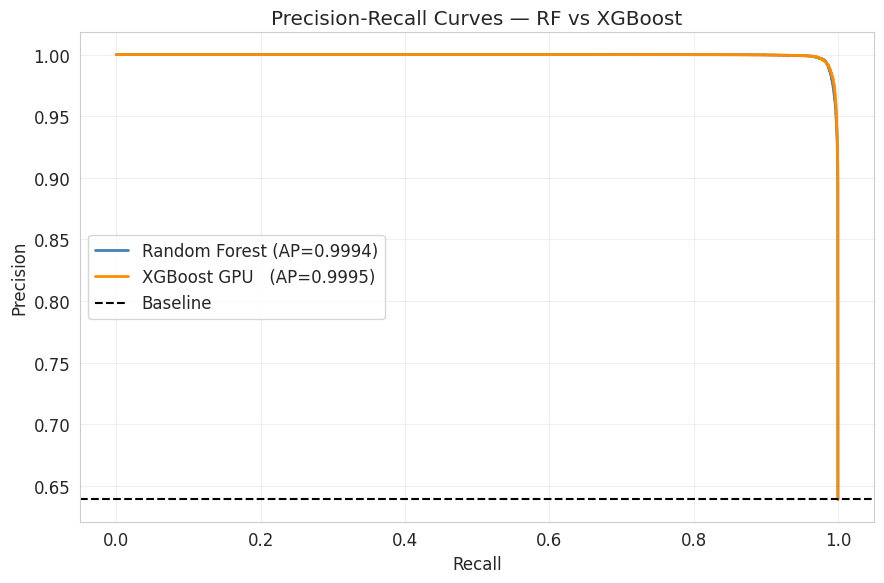

In [41]:
# Plot 3: Precision-Recall Curves

rf_prec_c,  rf_rec_c,  _ = precision_recall_curve(y_test, y_prob_rf)
xgb_prec_c, xgb_rec_c, _ = precision_recall_curve(y_test, y_prob_xgb)
rf_ap  = average_precision_score(y_test, y_prob_rf)
xgb_ap = average_precision_score(y_test, y_prob_xgb)

plt.figure(figsize=(9, 6))
plt.plot(rf_rec_c,  rf_prec_c,  color='steelblue',  lw=2, label=f'Random Forest (AP={rf_ap:.4f})')
plt.plot(xgb_rec_c, xgb_prec_c, color='darkorange', lw=2, label=f'XGBoost GPU   (AP={xgb_ap:.4f})')
plt.axhline(y=(y_test==1).mean(), color='k', linestyle='--', label='Baseline')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — RF vs XGBoost')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

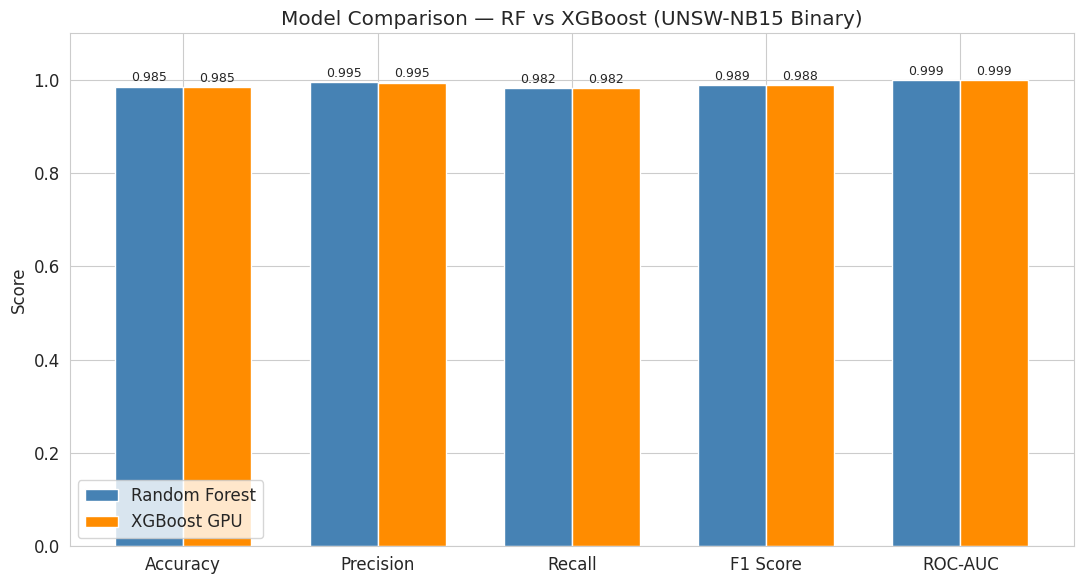

 metrics_comparison.png saved


In [42]:
# Plot 4: Metrics Comparison Bar Chart

metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

rf_metrics = [
    accuracy_score(y_test, y_pred_rf_opt),
    precision_score(y_test, y_pred_rf_opt),
    recall_score(y_test, y_pred_rf_opt),
    f1_score(y_test, y_pred_rf_opt),
    roc_auc_score(y_test, y_prob_rf)
]

xgb_metrics = [
    accuracy_score(y_test, y_pred_xgb_opt),
    precision_score(y_test, y_pred_xgb_opt),
    recall_score(y_test, y_pred_xgb_opt),
    f1_score(y_test, y_pred_xgb_opt),
    roc_auc_score(y_test, y_prob_xgb)
]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, rf_metrics,  width, label='Random Forest', color='steelblue')
bars2 = ax.bar(x + width/2, xgb_metrics, width, label='XGBoost GPU',   color='darkorange')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — RF vs XGBoost (UNSW-NB15 Binary)')
ax.legend()
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(' metrics_comparison.png saved')

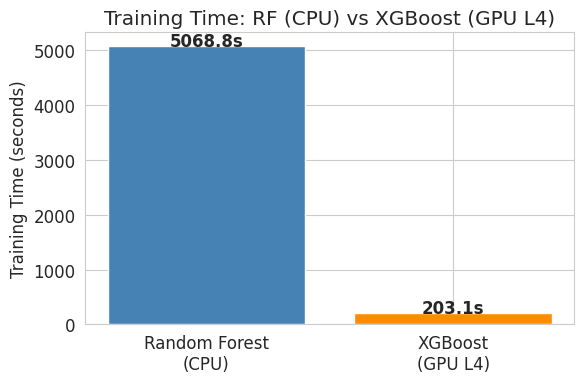

In [43]:
# Plot 5: Training Time Comparison

fig, ax = plt.subplots(figsize=(6, 4))
models = ['Random Forest\n(CPU)', 'XGBoost\n(GPU L4)']
times  = [rf_time, xgb_time]
colors = ['steelblue', 'darkorange']
bars = ax.bar(models, times, color=colors)
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{t:.1f}s', ha='center', fontweight='bold')
ax.set_ylabel('Training Time (seconds)')
ax.set_title('Training Time: RF (CPU) vs XGBoost (GPU L4)')
plt.tight_layout()
plt.savefig('training_time.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Feature Importance Comparison

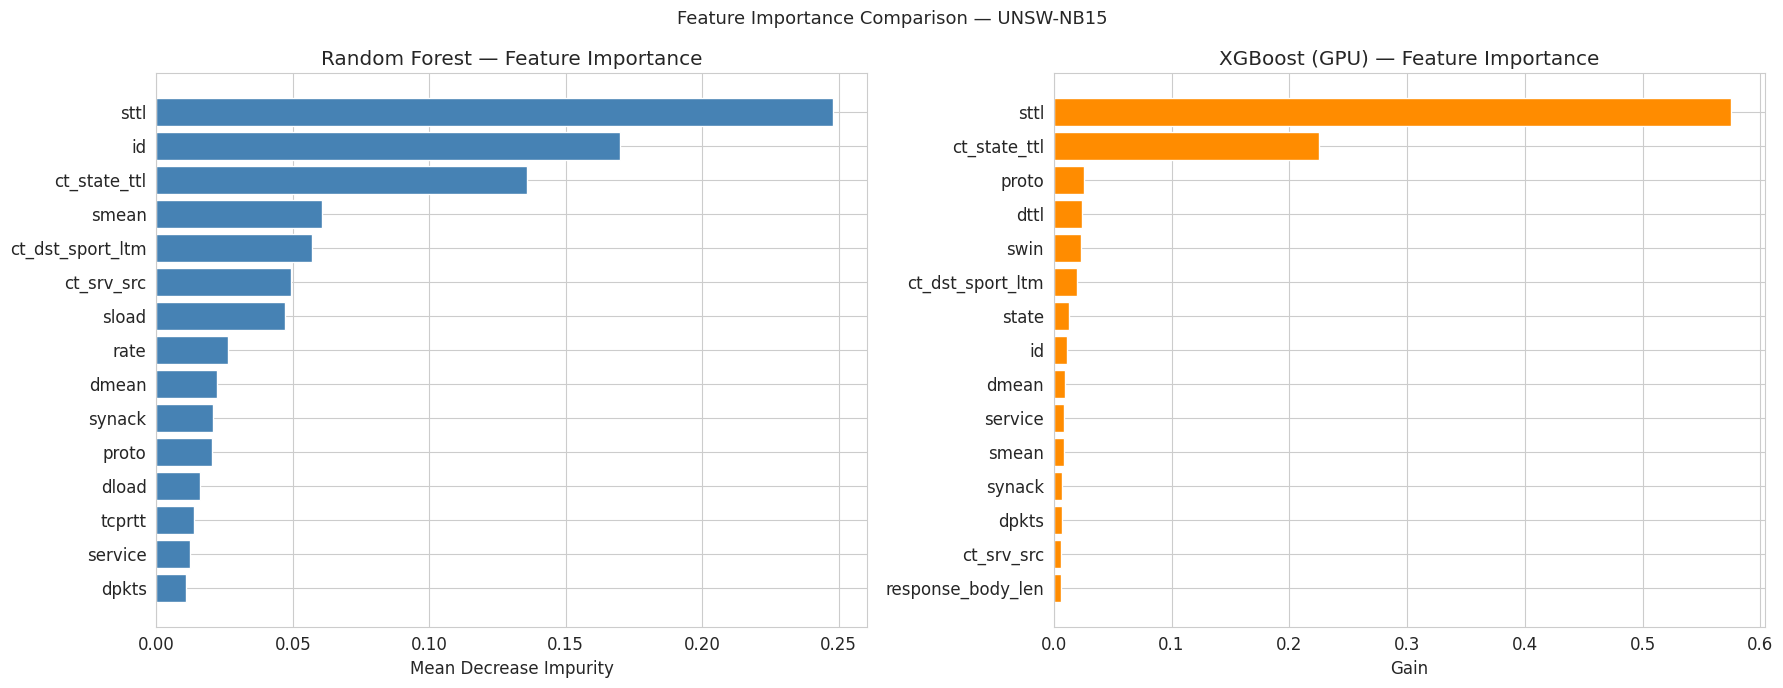

 feature_importance_comparison.png saved


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# RF importance
rf_imp = pd.DataFrame({'feature': selected_features, 'importance': best_rf.feature_importances_})
rf_imp.sort_values('importance', ascending=False, inplace=True)
top15_rf = rf_imp.head(15)
axes[0].barh(top15_rf['feature'][::-1], top15_rf['importance'][::-1], color='steelblue')
axes[0].set_title('Random Forest — Feature Importance')
axes[0].set_xlabel('Mean Decrease Impurity')

# XGBoost importance
xgb_imp = pd.DataFrame({
    'feature'   : selected_features,
    'importance': best_xgb.feature_importances_
})
xgb_imp.sort_values('importance', ascending=False, inplace=True)
top15_xgb = xgb_imp.head(15)
axes[1].barh(top15_xgb['feature'][::-1], top15_xgb['importance'][::-1], color='darkorange')
axes[1].set_title('XGBoost (GPU) — Feature Importance')
axes[1].set_xlabel('Gain')

plt.suptitle('Feature Importance Comparison — UNSW-NB15', fontsize=13)
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(' feature_importance_comparison.png saved')

---
## 11. Cross-Validation (Best Model)

In [45]:
# Determine best model by F1
rf_f1_test  = f1_score(y_test, y_pred_rf_opt)
xgb_f1_test = f1_score(y_test, y_pred_xgb_opt)
best_model  = best_xgb if xgb_f1_test >= rf_f1_test else best_rf
best_name   = 'XGBoost GPU' if xgb_f1_test >= rf_f1_test else 'Random Forest'

print(f'Best model: {best_name} (F1={max(rf_f1_test, xgb_f1_test):.4f})')
print('\nRunning 5-Fold Cross-Validation...')

cv_scores = cross_val_score(
    best_model, X_train_res, y_train_res,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1', n_jobs=-1
)

for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'\nMean  : {cv_scores.mean():.4f}')
print(f'Std   : {cv_scores.std():.4f}')

Best model: Random Forest (F1=0.9885)

Running 5-Fold Cross-Validation...
  Fold 1: 0.9826
  Fold 2: 0.9838
  Fold 3: 0.9823
  Fold 4: 0.9842
  Fold 5: 0.9826

Mean  : 0.9831
Std   : 0.0008


---
## 12. Final Results Summary

In [46]:
print('=' * 65)
print('              FINAL RESULTS SUMMARY')
print('=' * 65)
print(f'{"Metric":<25} {"Random Forest":>18} {"XGBoost GPU":>18}')
print('─' * 65)

rows = [
    ('Accuracy',        accuracy_score(y_test, y_pred_rf_opt),  accuracy_score(y_test, y_pred_xgb_opt)),
    ('Precision',       precision_score(y_test, y_pred_rf_opt), precision_score(y_test, y_pred_xgb_opt)),
    ('Recall / DR',     recall_score(y_test, y_pred_rf_opt),    recall_score(y_test, y_pred_xgb_opt)),
    ('F1 Score',        f1_score(y_test, y_pred_rf_opt),        f1_score(y_test, y_pred_xgb_opt)),
    ('ROC-AUC',         roc_auc_score(y_test, y_prob_rf),       roc_auc_score(y_test, y_prob_xgb)),
    ('Avg Precision',   rf_ap,                                   xgb_ap),
    ("Youden Threshold",rf_thresh,                               xgb_thresh),
    ('Training Time(s)',rf_time,                                  xgb_time),
]

for name, rf_val, xgb_val in rows:
    print(f'{name:<25} {rf_val:>18.4f} {xgb_val:>18.4f}')

print('─' * 65)
print(f'{"CV F1 Mean (best)":<25} {cv_scores.mean():>18.4f}')
print(f'{"CV F1 Std":<25} {cv_scores.std():>18.4f}')
print('=' * 65)
print(f'\n Best Overall Model: {best_name}')

              FINAL RESULTS SUMMARY
Metric                         Random Forest        XGBoost GPU
─────────────────────────────────────────────────────────────────
Accuracy                              0.9854             0.9852
Precision                             0.9950             0.9945
Recall / DR                           0.9821             0.9822
F1 Score                              0.9885             0.9883
ROC-AUC                               0.9989             0.9991
Avg Precision                         0.9994             0.9995
Youden Threshold                      0.5093             0.5589
Training Time(s)                   5068.7677           203.0626
─────────────────────────────────────────────────────────────────
CV F1 Mean (best)                     0.9831
CV F1 Std                             0.0008

 Best Overall Model: Random Forest


In [47]:
import joblib

joblib.dump(best_rf,  'rf_nids_unsw.pkl')
joblib.dump(best_xgb, 'xgb_nids_unsw.pkl')
joblib.dump(scaler,   'scaler_unsw.pkl')
pd.DataFrame({'feature': selected_features}).to_csv('selected_features_unsw.csv', index=False)

print(' rf_nids_unsw.pkl')
print(' xgb_nids_unsw.pkl')
print(' scaler_unsw.pkl')
print(' selected_features_unsw.csv')

 rf_nids_unsw.pkl
 xgb_nids_unsw.pkl
 scaler_unsw.pkl
 selected_features_unsw.csv
